In [15]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

from build_finesat_dataset import build_finesat_dataset

In [2]:
DATASET_DIR = os.path.join('..', 'geometry-consistent-data')
FILENAME = "gc_c3.2_data1.json"
RTCM_PATH = os.path.join(os.getcwd(), "..", "..", "gnss-data-collection",
                         "window-experiment", "data", "samples")

with open(os.path.join(DATASET_DIR, FILENAME), 'r') as f:
    data = json.load(f)

In [3]:
window0_data_paths = []
window0 = data[0]
for i in range(0, len(window0)):
    window0_data_paths.append(os.path.join(RTCM_PATH, window0[i][0]))

window1_data_paths = []
window1 = data[1]
for i in range(0, len(window1)):
    window1_data_paths.append(os.path.join(RTCM_PATH, window1[i][0]))

window2_data_paths = []
window2 = data[2]
for i in range(0, len(window2)):
    window2_data_paths.append(os.path.join(RTCM_PATH, window2[i][0]))

window3_data_paths = []
window3 = data[3]
for i in range(0, len(window3)):
    window3_data_paths.append(os.path.join(RTCM_PATH, window3[i][0]))

In [4]:
X0_fs, Y0_fs = build_finesat_dataset(window0_data_paths)
X1_fs, Y1_fs = build_finesat_dataset(window1_data_paths)
X2_fs, Y2_fs = build_finesat_dataset(window2_data_paths)
X3_fs, Y3_fs = build_finesat_dataset(window3_data_paths)

Processing 46 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (46, 78)  -> (46 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (46,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 60 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (60, 78)  -> (60 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (60,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 90 files for FINESAT Pipeline...


Unknown protocol header b'\xd3m'.
Unknown protocol header b'$\x04'.
Unknown protocol header b'\xd3\x80'.
Unknown protocol header b'$x'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'\xd3D'.
Unknown protocol header b'\xd3w'.
Unknown protocol header b'$\x06'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'$\xe2'.
Unknown protocol header b'$;'.
Unknown protocol header b'$\t'.
Unknown protocol header b'\xb5 '.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xd7'.
Unknown protocol header b'\xb5\x9f'.
Unknown protocol header b'\xd3Z'.
Unknown protocol header b'\xd3\xde'.
Unknown protocol header b'\xb5\x9b'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5^'.
Unknown protocol header b'\xd3\x9d'.
Serial stream terminated unexpectedly. 1874 bytes requested, 955 bytes returned.
Unknown protocol header b'$K'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x95'.
Unknown protocol heade


FineSat Dataset Built!
Feature Matrix (X) Shape: (90, 78)  -> (90 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (90,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 78 files for FINESAT Pipeline...


Unknown protocol header b'\xb5\x8b'.
Serial stream terminated unexpectedly. 170 bytes requested, 126 bytes returned.
Unknown protocol header b'$g'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\x8a'.
Unknown protocol header b'\xb5\x97'.
Unknown protocol header b'\xd3\xed'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xf7'.
Unknown protocol header b'$0'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.



FineSat Dataset Built!
Feature Matrix (X) Shape: (78, 78)  -> (78 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (78,)
Saved as ./X_finesat.npy and ./Y_finesat.npy


Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.50
Fold 2: Accuracy = 0.44
Fold 3: Accuracy = 0.67
Fold 4: Accuracy = 0.56
Fold 5: Accuracy = 0.33

Average Accuracy: 0.50 ± 0.11


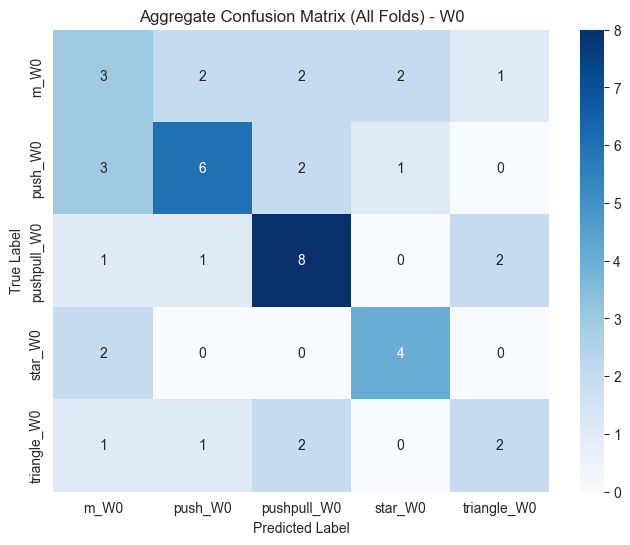

In [16]:
le = LabelEncoder()
Y0_encoded = le.fit_transform(Y0_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies0 = []
# To aggregate confusion matrix over all folds
cm_total0 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X0_fs, Y0_encoded)):
    X0_train, X0_test = X0_fs[train_idx], X0_fs[test_idx]
    y0_train, y0_test = Y0_encoded[train_idx], Y0_encoded[test_idx]

    # Simple default XGBoost model
    model0 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model0.fit(X0_train, y0_train)

    preds0 = model0.predict(X0_test)
    acc0 = accuracy_score(y0_test, preds0)
    accuracies0.append(acc0)

    cm0 = confusion_matrix(y0_test, preds0, labels=range(len(le.classes_)))
    cm_total0 += cm0

    print(f"Fold {fold+1}: Accuracy = {acc0:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies0):.2f} ± {np.std(accuracies0):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total0, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.42
Fold 2: Accuracy = 0.58
Fold 3: Accuracy = 0.50
Fold 4: Accuracy = 0.17
Fold 5: Accuracy = 0.50

Average Accuracy: 0.43 ± 0.14


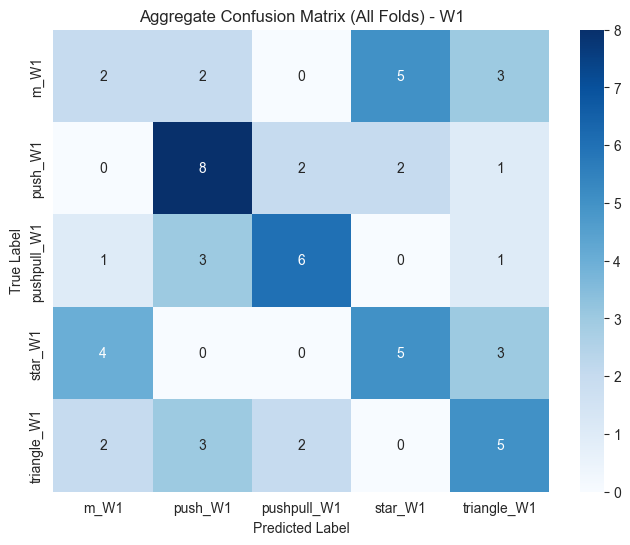

In [17]:
le = LabelEncoder()
Y1_encoded = le.fit_transform(Y1_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies1 = []
# To aggregate confusion matrix over all folds
cm_total1 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X1_fs, Y1_encoded)):
    X1_train, X1_test = X1_fs[train_idx], X1_fs[test_idx]
    y1_train, y1_test = Y1_encoded[train_idx], Y1_encoded[test_idx]

    # Simple default XGBoost model
    model1 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model1.fit(X1_train, y1_train)

    preds1 = model1.predict(X1_test)
    acc1 = accuracy_score(y1_test, preds1)
    accuracies1.append(acc1)

    cm1 = confusion_matrix(y1_test, preds1, labels=range(len(le.classes_)))
    cm_total1 += cm1

    print(f"Fold {fold+1}: Accuracy = {acc1:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies1):.2f} ± {np.std(accuracies1):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total1, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.50
Fold 2: Accuracy = 0.61
Fold 3: Accuracy = 0.39
Fold 4: Accuracy = 0.39
Fold 5: Accuracy = 0.33

Average Accuracy: 0.44 ± 0.10


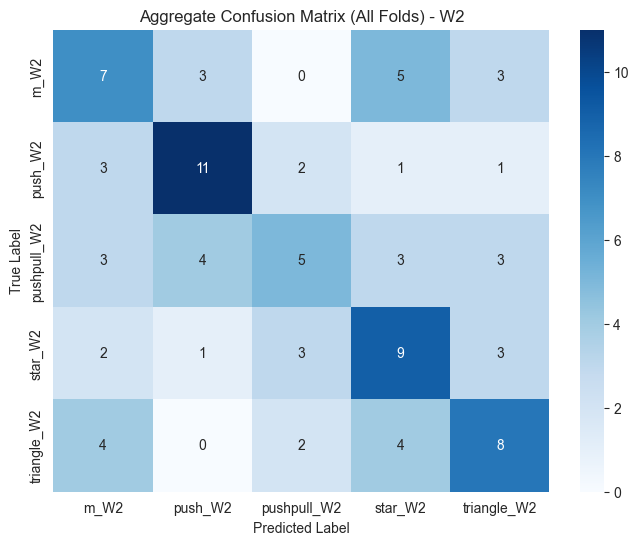

In [18]:
le = LabelEncoder()
Y2_encoded = le.fit_transform(Y2_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies2 = []
# To aggregate confusion matrix over all folds
cm_total2 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X2_fs, Y2_encoded)):
    X2_train, X2_test = X2_fs[train_idx], X2_fs[test_idx]
    y2_train, y2_test = Y2_encoded[train_idx], Y2_encoded[test_idx]

    # Simple default XGBoost model
    model2 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model2.fit(X2_train, y2_train)

    preds2 = model2.predict(X2_test)
    acc2 = accuracy_score(y2_test, preds2)
    accuracies2.append(acc2)

    cm2 = confusion_matrix(y2_test, preds2, labels=range(len(le.classes_)))
    cm_total2 += cm2

    print(f"Fold {fold+1}: Accuracy = {acc2:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies2):.2f} ± {np.std(accuracies2):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total2, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.44
Fold 2: Accuracy = 0.62
Fold 3: Accuracy = 0.56
Fold 4: Accuracy = 0.53
Fold 5: Accuracy = 0.47

Average Accuracy: 0.53 ± 0.07


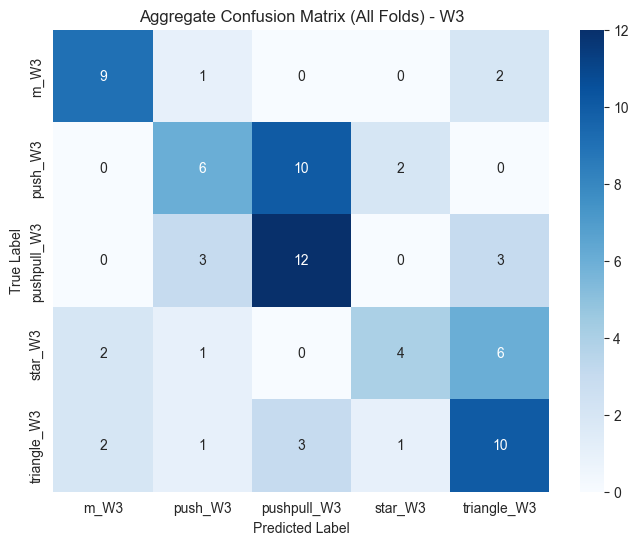

In [19]:
le = LabelEncoder()
Y3_encoded = le.fit_transform(Y3_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies3 = []
# To aggregate confusion matrix over all folds
cm_total3 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X3_fs, Y3_encoded)):
    X3_train, X3_test = X3_fs[train_idx], X3_fs[test_idx]
    y3_train, y3_test = Y3_encoded[train_idx], Y3_encoded[test_idx]

    # Simple default XGBoost model
    model3 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model3.fit(X3_train, y3_train)

    preds3 = model3.predict(X3_test)
    acc3 = accuracy_score(y3_test, preds3)
    accuracies3.append(acc3)

    cm3 = confusion_matrix(y3_test, preds3, labels=range(len(le.classes_)))
    cm_total3 += cm3

    print(f"Fold {fold+1}: Accuracy = {acc3:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies3):.2f} ± {np.std(accuracies3):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total3, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()